<a href="https://colab.research.google.com/github/leesuyee/dynamic-routing-tutorials/blob/main/code/Intro-Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Attention and Sensory Processing

**University of Puget Sound NRSC 490 · Advanced Topics in Neuroscience**

**Su-Yee Lee**

**Resources**:

[Allen Neural Dynamics data portal](https://data.allenneuraldynamics-test.org/view?asset=ecephys_713655_2024-08-09_10-41-47_nwb_2026-08-04_15-02-39&subject_id=713655&unit_id=713655_2024-08-09_C-362)

[SWDB Data Book](https://allenswdb.github.io/physiology/ephys/dynamic-routing/dynamic-routing-background.html)

## Learning objectives

- Open and navigate an NWB file — the standard format for shared neural data
- Plot neural activity as both discrete spikes (raster) and a continuous firing rate
- Build a peri-stimulus time histogram (PSTH) to visualize event-triggered responses
- Compare PSTHs across stimuli to characterize a neuron's stimulus tuning
- Classify neurons based on stimulus response profiles
- Quantify context-dependent changes in neural activity using an Attention Modulation Index (AMI)

---
## Setup Environment - RUN THIS ONCE

In [63]:
# Run once on Colab
!pip -q install numpy==2.1.3 pandas==2.2.3 matplotlib==3.10 scipy==1.16.3 zarr==2.18.7 aiohttp==3.14.3 hdmf_zarr==0.13.0 s3fs==2026.7.0 aind_data_access_api==1.10 datetime

In [64]:
# Import packages

# NWB API
from hdmf_zarr import NWBZarrIO

# Scientific computing and plotting packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Set figure parameters
plt.rcParams['figure.dpi'] = 110

---
## 1. Load an NWB session

Each recording session is stored as a **NWB Zarr** file on a public S3 bucket. Below is a list of all the S3 paths to the data available for this tutorial. To access the data, we'll use the NWBZarrIO, the NWB API, like so:

In [65]:
S3_PATHS = [
    "s3://aind-open-data/ecephys_708016_2024-04-29_12-59-12_nwb_2026-08-04_15-02-46/708016_2024-04-29.nwb.zarr",
    "s3://aind-open-data/ecephys_741137_2024-10-10_13-15-50_nwb_2026-08-04_15-10-12/741137_2024-10-10.nwb.zarr",
    "s3://aind-open-data/ecephys_715710_2024-07-16_12-58-34_nwb_2026-08-04_15-11-54/715710_2024-07-16.nwb.zarr",
    "s3://aind-open-data/ecephys_713655_2024-08-09_10-41-47_nwb_2026-08-04_15-02-39/713655_2024-08-09.nwb.zarr",
    "s3://aind-open-data/ecephys_714748_2024-06-24_12-52-23_nwb_2026-08-04_15-06-39/714748_2024-06-24.nwb.zarr",
    "s3://aind-open-data/ecephys_759434_2025-02-04_12-27-22_nwb_2026-08-04_15-01-21/759434_2025-02-04.nwb.zarr",
    "s3://aind-open-data/ecephys_742903_2024-10-23_14-12-23_nwb_2026-08-04_15-14-57/742903_2024-10-23.nwb.zarr",
    "s3://aind-open-data/ecephys_664851_2023-11-16_12-54-53_nwb_2026-08-04_15-09-33/664851_2023-11-16.nwb.zarr",
    "s3://aind-open-data/ecephys_662892_2023-08-24_14-28-28_nwb_2026-08-04_15-13-29/662892_2023-08-24.nwb.zarr",
    "s3://aind-open-data/ecephys_712815_2024-05-22_12-26-32_nwb_2026-08-04_14-59-22/712815_2024-05-22.nwb.zarr",
    "s3://aind-open-data/ecephys_743199_2024-12-05_12-42-34_nwb_2026-08-04_15-00-49/743199_2024-12-05.nwb.zarr",
    "s3://aind-open-data/ecephys_667252_2023-09-28_15-00-38_nwb_2026-08-04_15-21-37/667252_2023-09-28.nwb.zarr",
]

# Pick one session for the whole tutorial.
s3_path = S3_PATHS[3]      # 713655_2024-08-09

io = NWBZarrIO(path=s3_path, mode='r', storage_options={'anon': True})
nwbfile = io.read()
nwbfile

# takes ~4m to load

/usr/local/lib/python3.13/dist-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (460263, 500) float32 read-only>
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (460280, 500) float32 read-only>
  warnings.warn(


,timestamps
id,
0,NaN
1,14.17525
2,14.19192
3,14.20858
,timestamps
id,
0,NaN
1,14.40125
2,14.41791


### Open an NWB File

The data for each experimental session is stored as a **[Neurodata Without Borders (NWB)](https://www.nwb.org)** file. NWB is a community standard for physiology data capable of storing neural activity (spikes, fluorescence traces), behavior, stimulus tables, and metadata in one file using a hierarchical layout (like folders in a file system).

Explore the contents of the NWB file above.

While there are many `containers` with data to explore, for this tutorial we will use:
- `units` — data for every recorded neuron (spike times, brain area, QC, waveform metrics, …)
- `intervals` — tables which report trial-by-trial information about the behavior task

---
## 2. The `units` table

Neural activity data is stored in the `units` table. Each row in the table contains columns of data for one presumed neuron.

Note that this table is large! It contains data from up to 6 Neuropixels probes with hundreds of contacts recorded simultaneously over an hour.


In [66]:
# Load units table

units_nwb = nwbfile.units
units_full = units_nwb.to_dataframe(exclude={'spike_times', 'spike_amplitudes', 'obs_intervals'})
idx = units_nwb.spike_times_index.data[:]
units_full['spike_times'] = np.split(units_nwb.spike_times.data[:], idx[:-1])

In [67]:
# Check total number of units in this session
print('Total units:', len(units_full))

Total units: 3577


In [68]:
# How many QC-pass units did we record in each brain area? (top 15)
(units_full[units_full['is_qc_pass']]
   .groupby('structure').size()
   .sort_values(ascending=False))


# Resource: https://atlas.brain-map.org/
# Check out the Adult Mouse Brain Atlas to see the full name of each structure and where it is located in the brain

,0
structure,
SSs,209
ECT,168
LSr,144
MOp,134
CP,105
MOs,95
AUDp,87
TEa,77
AUDv,62


There are many columns in the units table for neural activity data, QC metrics, and other information about the unit. For our purposes, we'll reduce the units table to 4 columns below.

(This should be sufficient data for most projects, but please consult the [data book](https://allenswdb.github.io/physiology/ephys/dynamic-routing/dynamic-routing-accessing-data.html) or reach out if you're interested in using more data)

| Column Name | Definition |
|---|---|
| `unit_id` | unique identifier for the unit |
| `spike_times` | array with time (seconds) that this unit fired an action potential |
| `structure` | acronym of brain region that this unit is located in |
| `is_qc_pass` | boolean that determines whether this unit passed QC filtering |

In [69]:
units = units_full[['unit_id', 'spike_times', 'structure', 'is_qc_pass']]
units = units[units.is_qc_pass == True]
units

,unit_id,spike_times,structure,is_qc_pass
id,,,,
3,713655_2024-08-09_A-3,"[21.589898466019914, 25.376921105508842, 26.38...",AV,True
6,713655_2024-08-09_A-8,"[20.5297681262966, 20.66936773209339, 20.76706...",AV,True
9,713655_2024-08-09_A-11,"[20.66703440534894, 20.68156769764297, 21.0538...",AV,True
16,713655_2024-08-09_A-19,"[20.2972354495921, 20.38506853490121, 20.39233...",AV,True
31,713655_2024-08-09_A-35,"[234.5388304713543, 307.03232576326747, 468.94...",AD,True
...,...,...,...,...
3562,713655_2024-08-09_F-819,"[1177.681903544815, 1300.9063581285607, 1448.6...",MOs,True
3566,713655_2024-08-09_F-823,"[22.307979845106125, 23.409442530344062, 24.76...",MOs,True
3569,713655_2024-08-09_F-826,"[23.933173970558883, 24.53560512629987, 27.333...",MOs,True


Looking for more data in the units table? Unhide and uncomment the cells below for further options.

---
## 3. Pick one neuron

**Exercise:** Let's select a neuron to plot - how would we find a neuron in primary auditory cortex (AUDp) and passes QC?

In [70]:
# audp_units = units[(units['is_qc_pass'] == ...) & (units['structure'] == ...)
# audp_units

In [71]:
# @title Show answer
audp_units = units[(units['is_qc_pass'] == True ) & (units['structure'] == 'AUDp')]
audp_units

,unit_id,spike_times,structure,is_qc_pass
id,,,,
1237,713655_2024-08-09_C-298,"[38.987480845555226, 68.24799277869838, 76.546...",AUDp,True
1238,713655_2024-08-09_C-299,"[20.317397984014693, 20.498862864177497, 20.59...",AUDp,True
1239,713655_2024-08-09_C-300,"[33.368769494548175, 37.967457554250686, 52.68...",AUDp,True
1240,713655_2024-08-09_C-302,"[20.495062901587755, 20.705627495266743, 21.00...",AUDp,True
1244,713655_2024-08-09_C-306,"[20.320331288469934, 20.327964546654595, 20.33...",AUDp,True
...,...,...,...,...
1927,713655_2024-08-09_C-1030,"[24.83105354752042, 30.07976854110515, 30.1459...",AUDp,True
1929,713655_2024-08-09_C-1032,"[20.295398200600395, 25.048584739280603, 29.53...",AUDp,True
1931,713655_2024-08-09_C-1034,"[53.40377225192015, 60.81379930093399, 93.5845...",AUDp,True


Let's select one neuron and look at its associated data. Each unit has a unique identifier: the unit_id. Note that you can pull the unit_id from the data portal and input here as well (if you have the correct session loaded).

We've pre-selected a good example neuron below for which we'll unpack and store the important features.

In [72]:
select_id     = '713655_2024-08-09_C-388'
area = units[units['unit_id'] == select_id].structure
spike_times = np.asarray(units[units['unit_id'] == select_id].spike_times)[0] # store spike times for unit

print(f'unit_id : {select_id}')
print(f'area    : {area}')
print(f'# spikes: {len(spike_times):,}')

unit_id : 713655_2024-08-09_C-388
area    : id
1314    AUDp
Name: structure, dtype: object
# spikes: 41,909


---
## 4. Plot spike times and firing rate for a selected neuron

The spike_times column in the units table reports an array of times (in seconds) when the unit fired an action potential. We can plot each spike time as a tick mark over time, generating a raster plot.

### 4.1 Raster: every spike in the session

Each vertical tick = one spike/action potential

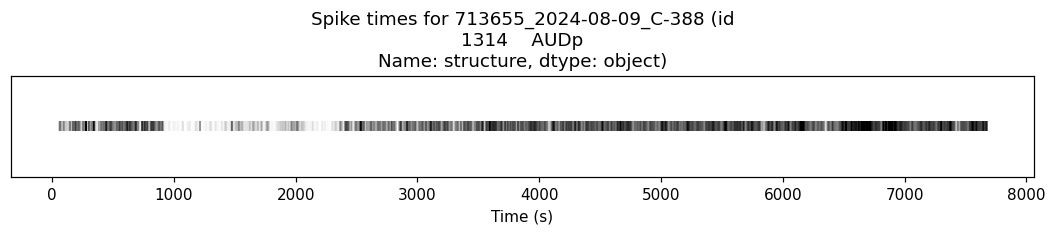

In [73]:
plt.figure(figsize=(12, 1.2))
plt.plot(spike_times, np.zeros_like(spike_times), '|', color='k', alpha=0.01)
plt.yticks([])
plt.xlabel('Time (s)')
plt.title(f'Spike times for {select_id} ({area})')
plt.show()

### 4.2 Convert to a firing rate

Individual spikes are hard to read at this scale. Convert to a **firing rate**: count spikes in short bins, divide by bin width to get Hz.

The function below `firing_rate` will convert spike times to firing_rate.

In [74]:
def firing_rate(spike_times, bin_size=1.0, bin_edges=None, n_trials=1):
    """Bin spikes and convert counts to Hz.

    If bin_edges is not given, bins span the entire range of spike_times
    Pass n_trials > 1 when spike_times is pooled across multiple trials, so counts are averaged per per trial and over time
    """
    if bin_edges is None:
        bin_edges = np.arange(spike_times[0], spike_times[-1] + bin_size, bin_size)
    spike_counts, _ = np.histogram(spike_times, bins=bin_edges)
    rate = spike_counts / (n_trials * bin_size)
    return bin_edges[:-1], rate

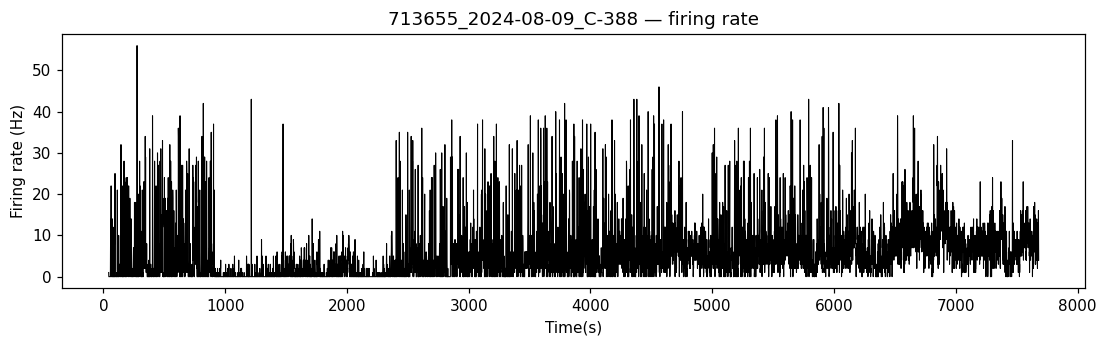

In [75]:
bin_times, rate_hz = firing_rate(spike_times, bin_size=1.0)

plt.figure(figsize=(12, 3))
plt.plot(bin_times, rate_hz, color='k', lw=0.7)
plt.xlabel('Time(s)')
plt.ylabel('Firing rate (Hz)')
plt.title(f'{select_id} — firing rate')
plt.show()

**Exercise:** change `bin_size` to `0.1` or `10.0` and re-run. How does changing the bin size change the plot?

In [76]:
# bin_times, firing_rate = firing_rate(spike_times, bin_size=...)   # change bin_size here

# plt.figure(figsize=(12, 3))
# plt.plot(bin_times, firing_rate, color='k', lw=0.7)
# plt.xlabel('Time (s)')
# plt.ylabel('Firing rate (Hz)')
# plt.title(f'{select_id} — firing rate')
# plt.show()

**Discuss:** What do you notice about the plot above?

---
## 5. The `trials` table

To add some context to the plot, let's add information from the `trials` table in the `intervals` container, which stores trial-by-trial information about the behavior task.

Every stimulus presentation is one row in `trials`. There are a lot of columns in the `trials` table, here are the ones we'll be focusing on in this tutorial. (Again, view the data book for a full description of the column descriptions https://allenswdb.github.io/physiology/ephys/dynamic-routing/dynamic-routing-accessing-data.html)

| Column Name | Definition |
|---|---|
| `stim_name` | reports the presented stimulus (`vis1`, `vis2`, `sound1`, `sound2`) |
| `stim_start_time` | when the stimulus was presented (s) |
| `rewarded_modality` | reports which modality was rewarded `vis` or `aud` |

In [77]:
trials = nwbfile.intervals['trials'].to_dataframe()
trials.head()

,start_time,stop_time,quiescent_start_time,quiescent_stop_time,stim_start_time,stim_stop_time,response_window_start_time,response_window_stop_time,task_control_response_time,response_time,...,is_vis_target,is_nontarget,is_aud_nontarget,is_vis_nontarget,is_vis_rewarded,is_aud_rewarded,is_block_switch,is_repeat,is_opto,is_task_control_correct
id,,,,,,,,,,,,,,,,,,,,,
0,2403.42415,2408.92875,2403.42415,2404.89204,2404.93261,2405.43261,2405.00879,2405.92623,2405.47583,2405.46553,...,False,False,False,False,False,True,False,False,False,False
1,2409.89623,2415.40125,2409.89623,2411.36411,2411.40501,2411.90501,2411.48088,2412.39832,2411.74797,2411.73257,...,False,False,False,False,False,True,False,False,False,False
2,2417.98632,2423.49098,2417.98632,2419.45423,2419.49515,2419.99515,2419.57102,2420.48843,2420.03805,2420.03365,...,False,False,False,False,False,True,False,False,False,False
3,2429.22911,2434.73372,2429.22911,2430.69701,2430.73779,2431.23779,2430.81378,2431.73118,2431.43094,2431.43076,...,False,False,False,False,False,True,False,False,False,False
4,2435.43427,2440.93889,2435.43427,2436.90215,2436.94313,2437.44313,2437.01895,2437.93632,2437.60277,2437.60187,...,False,False,False,False,False,True,False,False,False,False


**Exercise:**  How many times was each stimulus presented?

In [78]:
# trials[...].value_counts()

In [79]:
# @title Show answer
trials['stim_name'].value_counts()

,count
stim_name,
vis1,125
sound1,118
sound2,109
vis2,108
catch,55


### 5.1 Overlay stimulus onsets on the firing rate

Building on our firing rate plot, let's add colored vertical lines to indicate when visual vs auditory stimuli were presented.

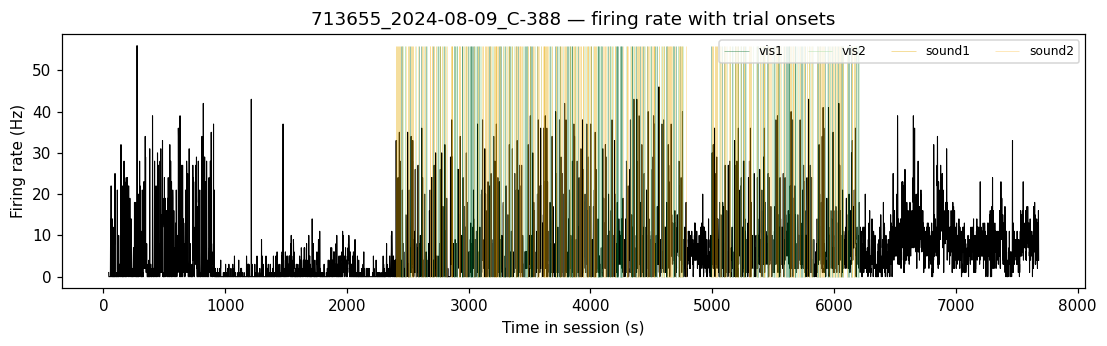

In [80]:
# Define stimulus colors: greens for visual, yellows for auditory.
stim_colors = {
    'vis1': '#006d2c', 'vis2': '#a1d99b',
    'sound1': '#e6ab02', 'sound2': '#fec44f',
}

# Define context colors (used later on in Sections 9 and 11)
context_colors = {
    'attend-vis': '#238b45',   # green — visual rewarded modality
    'attend-aud': '#d95f0e',   # orange — auditory rewarded modality
}

# Set up figure
plt.figure(figsize=(12, 3))
# Plot firing rate for selected neuron (same as above)
plt.plot(bin_times, rate_hz, color='k', lw=0.7)
# Iterate through each stimulus type and plot a vertical line in corresponding color
for stim, color in stim_colors.items():
    onsets = trials.loc[trials['stim_name'] == stim, 'stim_start_time']
    plt.vlines(onsets, 0, rate_hz.max(),
               color=color, alpha=0.5, lw=0.5, label=stim)
plt.xlabel('Time in session (s)')
plt.ylabel('Firing rate (Hz)')
plt.title(f'{select_id} — firing rate with trial onsets')
plt.legend(loc='upper right', ncol=4, fontsize=8)
plt.show()

**Discuss**

What do you notice about the plot? Are there differences in responses between each stimuli?

With hundreds of trials packed together, it's difficult to tell waht this neuron responds to. To help us visualize which stimuli this neuron responds to, we can **align neural activity to the stimulus onsets** and average across repeated stimulus presentations.

---
## 6. Build a Peri-Stimulus Time Histogram (PSTH)

A **(PSTH)** aligns neural activity to a common event, like a stimulus onset, across many trials. Additionally, if there are multiple repeats of the stimulus, we can average across responses. We'll walk through how to create a PSTH one step at a time, looking at the selected neuron's responses to `sound` trials.

### 6.1 Get the event times (sound1 stimulus start times)

In [81]:
# Get all the stimulus start times for sound1 trials, convert to an array
sound1_onsets = trials[trials['stim_name'] == 'sound1'].stim_start_time.to_numpy()
sound1_onsets


array([2404.93261, 2411.40501, 2419.49515, 2430.73779, 2436.94313,
       2498.59449, 2527.63534, 2535.15855, 2540.84741, 2614.82521,
       2638.39572, 2717.19522, 2729.07171, 2767.33734, 2778.59625,
       2804.50082, 2850.69015, 2860.6981 , 2866.58639, 2929.77298,
       2981.21562, 3072.67569, 3113.89328, 3132.70932, 3138.39795,
       3159.28151, 3205.9209 , 3215.97975, 3221.81784, 3227.90579,
       3240.36643, 3333.6282 , 3359.16599, 3397.53094, 3417.49873,
       3435.2968 , 3488.50816, 3506.6062 , 3526.58998, 3572.07813,
       3615.0472 , 3621.46963, 3629.04258, 3636.28108, 3642.00318,
       3684.5224 , 3714.89714, 3746.02315, 3787.7752 , 3799.93572,
       3828.37637, 3863.83937, 3870.0103 , 3922.0545 , 3934.69779,
       3969.91166, 3983.48961, 4001.78806, 4037.78453, 4045.40748,
       4122.4894 , 4176.83491, 4197.46811, 4297.31834, 4328.77794,
       4356.7521 , 4380.68842, 4398.95409, 4422.20708, 4473.73362,
       4518.88781, 4525.72629, 4562.67449, 4586.61104, 4600.68

In [82]:
print(f'{len(sound1_onsets)} sound1 trials in this session')

118 sound1 trials in this session


### 6.2 For one event, get spike times in a time window centered around event.

1. Set up a few variables: t0 = event time, define a time window (e.g. 500ms before t0 to 1000ms after).
2. Collect spike times within the defined time window.
3. Subtract the value of t0 from spike times to get spike times **relative** to the event.

In [83]:
window = (-0.5, 1.0)   # time window 500 ms before to 1000 ms after stimulus onset

t0 = sound1_onsets[0] # first sound1 onset
spikes_in_window = spike_times[(spike_times >= t0 + window[0]) &
                               (spike_times <  t0 + window[1])]           # store spikes inside the time window
spikes_aligned = spikes_in_window - t0                                  # subtract t0 to get relative spike times

print(f'Trial 0 onset : {t0} s')
print(f'# spikes in the window : {len(spikes_in_window)}')
print(f'aligned times : {spikes_aligned}')

Trial 0 onset : 2404.93261 s
# spikes in the window : 38
aligned times : [0.06877767 0.07967756 0.08834415 0.14377693 0.15961011 0.16867669
 0.18900982 0.22407614 0.23224273 0.23894266 0.25274253 0.25904247
 0.29140881 0.32197518 0.33014177 0.34254164 0.34934158 0.37584132
 0.3910745  0.39920775 0.42957412 0.44334065 0.46714042 0.48400692
 0.49357349 0.5060067  0.52073989 0.52887314 0.57507269 0.62793883
 0.65110527 0.69703815 0.72000459 0.76130419 0.78853725 0.87903636
 0.9297692  0.9629022 ]


### 6.3 Repeat for every trial

**Exercise:** Now repeat this process for  all 188 sound1 trials in this session. Then, plot each row as a raster plot aligned to the stimulus onset.

In [84]:
# aligned_spikes = []   # collect one array of aligned spike times per trial

# for t0 in [...]: # iterate through all event times (sound1 onsets)
#     spikes_in_window = spike_times[(spike_times >= t0 + window[0]) &
#                                    (spike_times <  t0 + window[1])] # get spikes in time window
#     spikes_aligned   = spikes_in_window - t0 # subtract t0 to align
#     aligned_spikes.append(...) # iteratively store each array

In [85]:
# @title Show answer
aligned_spikes = []   # collect one array of aligned spike times per trial

for t0 in sound1_onsets:
    spikes_in_window = spike_times[(spike_times >= t0 + window[0]) &
                                   (spike_times <  t0 + window[1])]
    spikes_aligned   = spikes_in_window - t0
    aligned_spikes.append(spikes_aligned)

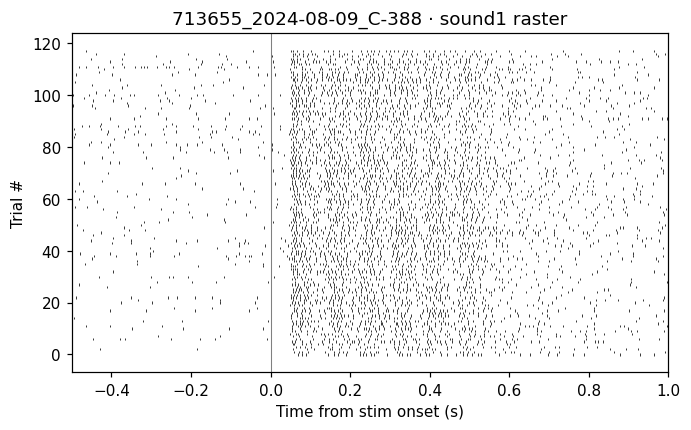

In [86]:
# # Plot raster for all trials
plt.figure(figsize=(7, 4))
plt.eventplot(aligned_spikes, colors='k', linewidths=0.5, linelengths=0.9)
plt.axvline(0, color='0.5', lw=0.7)
plt.xlim(window)
plt.xlabel('Time from stim onset (s)')
plt.ylabel('Trial #')
plt.title(f'{select_id} · sound1 raster')
plt.show()

### 6.4 Plot firing rate

From the aligned spike times across trials, calculate the average firing rate. First, count the number of spikes across trials in bins (e.g. 25ms). Divide by `n_trials x bin_width` to get the firing rate in Hz.

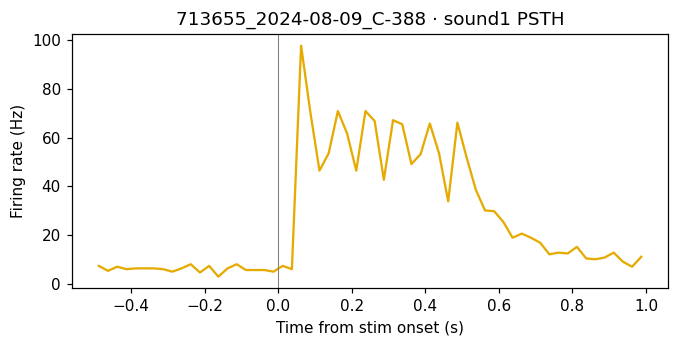

In [87]:
# Define bins that span window_size
bin_size = 0.025
bins = np.arange(window[0], window[1] + bin_size, bin_size)

all_spikes = np.concatenate(aligned_spikes)
_, psth_rate = firing_rate(all_spikes, bin_size=bin_size, bin_edges=bins, n_trials=len(aligned_spikes))
time_centers = 0.5 * (bins[:-1] + bins[1:])

plt.figure(figsize=(7, 3))
plt.plot(time_centers, psth_rate, color=stim_colors['sound1'])
plt.axvline(0, color='0.5', lw=0.7)
plt.xlabel('Time from stim onset (s)')
plt.ylabel('Firing rate (Hz)')
plt.title(f'{select_id} · sound1 PSTH')
plt.show()

### 6.5 Wrap the steps into a reusable function

Now that we've walked through the steps of how to create a PSTH, we can collapse this into a few functions.

In [88]:
def generate_psth(spike_times, event_times, window=(-0.5, 1.0), bin_size=0.025):
    """Peri-stimulus time histogram.

    Returns
    -------
    time_centers : bin centers relative to each event (s)
    psth_rate    : firing rate averaged across events (Hz)
    """
    bins = np.arange(window[0], window[1] + bin_size, bin_size)

    aligned_spikes = [
        spike_times[(spike_times >= t0 + window[0]) & (spike_times < t0 + window[1])] - t0
        for t0 in event_times
    ]

    all_spikes = np.concatenate(aligned_spikes) if aligned_spikes else np.array([])
    _, psth_rate = firing_rate(all_spikes, bin_size=bin_size, bin_edges=bins, n_trials=len(event_times))
    time_centers = 0.5 * (bins[:-1] + bins[1:])

    return time_centers, psth_rate

---
## 7. PSTH for each stimulus

This neuron responds strongly to sound1 - what about other stimuli? Now, we create a PSTH for each stimulus (vis1, vis2, sound1, sound2).

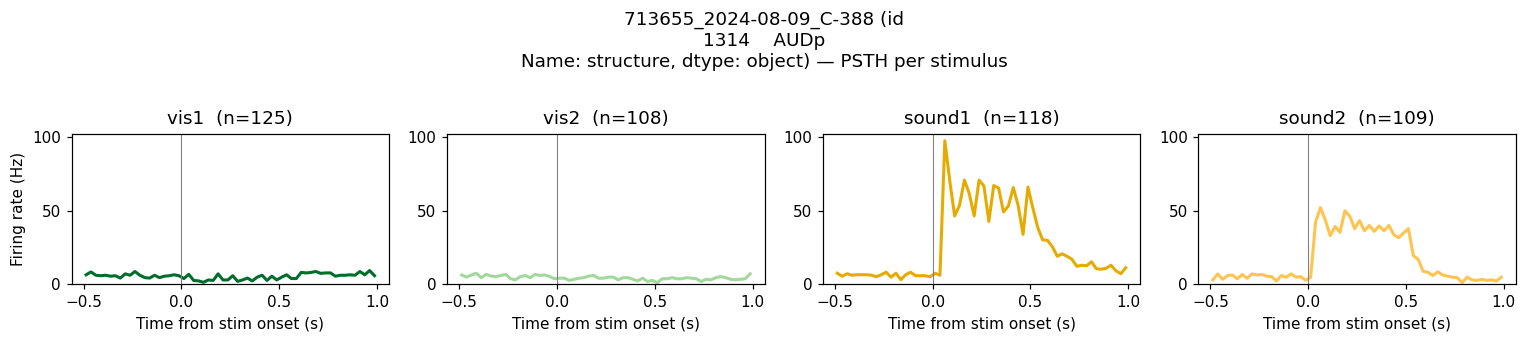

In [89]:
stimuli = ['vis1', 'vis2', 'sound1', 'sound2']

# Compute the PSTH for each stimulus
rates = {}      # empty dictionary to hold firing rates for each stimuli
n_trials = {}   # empty dicitonary to store n trials of each stimuli

for stim in stimuli: # iterate through each stimuli
    event_times = trials[trials['stim_name'] == stim].stim_start_time.to_numpy() # store stimulus onset times as array
    n_trials[stim] = len(event_times) # store number of trials
    time_centers, rates[stim] = generate_psth(spike_times, event_times) # generate psth for each stimuli
    # time centers is the same across all, store each firing rate separately

# Find maximum firing rate across stimuli to set y-limit
y_max = max(rate.max() for rate in rates.values())

# Setup figure
plt.figure(figsize=(14, 3))

for i, stim in enumerate(stimuli): # iterate through stimuli (enumerate gives us the position and the stimulus name)
    plt.subplot(1, 4, i + 1)  # create subplots and iterate through position

    plt.plot(time_centers, rates[stim], color=stim_colors[stim], lw=2) # plot psth for each stimuli
    plt.axvline(0, color='0.5', lw=0.7)   # vertical line marking stimulus onset (t=0)
    plt.ylim(0, y_max * 1.05)             # set common ylimit with some extra space

    # plot labelling code
    plt.title(f'{stim}  (n={n_trials[stim]})')
    plt.xlabel('Time from stim onset (s)')
    if i == 0:
        plt.ylabel('Firing rate (Hz)')  # only label the y-axis on the first subplot

plt.suptitle(f'{select_id} ({area}) — PSTH per stimulus', y=1.02)
plt.tight_layout()
plt.show()

**Discuss:** Is this neuron modality (visual or auditory) selective)? What else do you notice? Is that in line with what you expect for a neuron in primary auditory cortex?

---
## 8. Which stimuli does each neuron respond to?

Let's look at units across the brain and assess which stimuli they respond to. Do they respond to particular stimuli (**vis1 or vis 2 or sound 1 or sound 2**)? Do they respond to a particular stimulus modality (**visual but not auditory**)?

There are a few ways to quantify this, but let's focus on a specific, simple case: **which of the stimuli (vis1, vis2, sound1, sound2) is the neuron excited by?**

We need to find whether the firing rate was significantly higher just after the stimulus compared to a baseline period before the stimulus. We compare per-trial firing rates in matched time windows before and after the stimulus.....


and run a paired t-test to evaluate significance.

In [90]:
def count_in_window(spike_times, event_times, t_start, t_end):
    """Number of spikes in time window around each event."""
    counts = np.zeros(len(event_times), dtype=int)
    for i, t0 in enumerate(event_times):
        in_window = (spike_times >= t0 + t_start) & (spike_times < t0 + t_end)
        counts[i] = in_window.sum()
    return counts


def responsiveness_test(spike_times, event_times, response=(0.0, 0.25), baseline=(-0.25, 0.0)):
    """
    Performs paired t-test on firing rates in response and baseline windows around each event.
    Returns t-statistic and p-value
    """
    if len(event_times) < 5:
        return np.nan, np.nan
    response_rates = count_in_window(spike_times, event_times, *response) / (response[1] - response[0])
    baseline_rates = count_in_window(spike_times, event_times, *baseline) / (baseline[1] - baseline[0])
    return stats.ttest_rel(response_rates, baseline_rates)

In [91]:
# Assess which stimuli the selected neuron responds to
alpha = 0.05 # set alpha level to determine significance

for stim in ['vis1', 'vis2', 'sound1', 'sound2']: # apply function, iterating through stimuli
    event_times = trials[trials['stim_name'] == stim].stim_start_time.to_numpy()
    t_stat, p_value = responsiveness_test(spike_times, event_times)
    responsive = (t_stat > 0) and (p_value < alpha) # assess outcomes for significance
    print(f'  {stim}   responsive = {str(responsive)}   p = {p_value}')

  vis1   responsive = False   p = 2.2841940210477884e-05
  vis2   responsive = False   p = 0.135289980917164
  sound1   responsive = True   p = 9.698593130358764e-81
  sound2   responsive = True   p = 4.623799371870439e-66


The previous analysis confirms what we observed in the PSTH - this neuron is driven by both auditory stimuli and is not responsive to either visual stimulus.

**Discuss:**

How would changing the time windows of the response and baseline we're comparing change the analysis?

If you wanted to find neurons suppressed by the stimuli, what would you change in the function?

**Design choices in `responsiveness_test`:**

1. **250 ms response window** — long enough to capture both transient and sustained sensory responses without bleeding into the next trial. A longer window would wash out short, peaky responses; a shorter one would miss slower sustained ones.
2. **Matched-duration baseline just before onset** — comparing windows *within the same trial* removes slow drift in firing rate over the session.
3. **Paired t-test** — response and baseline come from the same trial, so the samples are dependent.
4. **`t_stat > 0`** — we're only asking about *excitation*. Flip the sign (`t_stat < 0`) to look for *suppression* instead.
5. **Minimum of 5 trials** — a paired t-test on fewer trials is not meaningful.


### 8.1 Classify every neuron

Run the same test on every QC-passing unit × every stimulus. The helper `test_all_units` below applies `responsiveness_test` to each (unit, stimulus) pair and returns the raw t-statistics and p-values.

In [92]:
def test_all_units(units_df, trials_df, stimuli=('vis1', 'vis2', 'sound1', 'sound2')):
    """Run responsiveness_test for every QC-pass unit x every stimulus.
    Returns one row per (unit, stimulus) with the raw test statistics.
    """
    stim_events = {
        stim: trials_df[trials_df['stim_name'] == stim].stim_start_time.to_numpy()
        for stim in stimuli
    }
    rows = []
    for _, unit_row in units_df[units_df['is_qc_pass']].iterrows():
        spike_times = np.asarray(unit_row['spike_times'])
        for stim, event_times in stim_events.items():
            t_stat, p_value = responsiveness_test(spike_times, event_times)
            rows.append({
                'unit_id': unit_row['unit_id'], 'structure': unit_row['structure'],
                'stim': stim, 't_stat': t_stat, 'p_value': p_value,
            })
    return pd.DataFrame(rows)

unit_stim_tests = test_all_units(units, trials)
unit_stim_tests.head()

,unit_id,structure,stim,t_stat,p_value
0,713655_2024-08-09_A-3,AV,vis1,-0.489808,0.625135
1,713655_2024-08-09_A-3,AV,vis2,0.199109,0.842556
2,713655_2024-08-09_A-3,AV,sound1,1.617243,0.108519
3,713655_2024-08-09_A-3,AV,sound2,0.615452,0.539551
4,713655_2024-08-09_A-8,AV,vis1,2.173561,0.031638


**Correcting for multiple comparisons.** When we tested a single neuron above, one p-value < 0.05 was enough to call it responsive. Now we're running the same test **thousands** of times (every unit × every stimulus), and even purely random data would produce significant hits by chance.

A simple, conservative fix is the **Bonferroni correction**: multiply each p-value by the total number of tests before comparing it to α. This trades some sensitivity for a much lower false-positive rate.

In [93]:
alpha = 0.05
n_tests = unit_stim_tests['p_value'].notna().sum() # get number of tests to correct for

# Apply Bonferroni correction
unit_stim_tests['p_bonferroni'] = (unit_stim_tests['p_value'] * n_tests).clip(upper=1) # Bonferroni correction: multiply p-value by # samples (if >1, throw out as not responsive)
# Identify which units are 'responsive'
unit_stim_tests['responsive'] = (
    (unit_stim_tests['t_stat'] > 0) & (unit_stim_tests['p_bonferroni'] <= alpha)
)

n_responsive = unit_stim_tests['responsive'].sum()
print(f'{n_responsive} of {n_tests} (unit, stimulus) pairs are responsive '
      f'(Bonferroni-corrected, alpha={alpha})')

unit_stim_tests.head()

433 of 4705 (unit, stimulus) pairs are responsive (Bonferroni-corrected, alpha=0.05)


,unit_id,structure,stim,t_stat,p_value,p_bonferroni,responsive
0,713655_2024-08-09_A-3,AV,vis1,-0.489808,0.625135,1.0,False
1,713655_2024-08-09_A-3,AV,vis2,0.199109,0.842556,1.0,False
2,713655_2024-08-09_A-3,AV,sound1,1.617243,0.108519,1.0,False
3,713655_2024-08-09_A-3,AV,sound2,0.615452,0.539551,1.0,False
4,713655_2024-08-09_A-8,AV,vis1,2.173561,0.031638,1.0,False


Now, label each unit by which stimuli it responds to



In [94]:
STIM_MODALITY = {'vis1': 'vis', 'vis2': 'vis', 'sound1': 'aud', 'sound2': 'aud'}

def describe_response_profile(responsive_stims):
    """Turn a unit's set of responsive stimuli into a readable category label."""
    if not responsive_stims:
        return 'none'
    modalities = {STIM_MODALITY[s] for s in responsive_stims}
    if modalities == {'vis'}:
        return 'both visual' if len(responsive_stims) == 2 else f'{next(iter(responsive_stims))} only'
    if modalities == {'aud'}:
        return 'both auditory' if len(responsive_stims) == 2 else f'{next(iter(responsive_stims))} only'
    return 'mixed'


# Reshape to one row per unit, one column per stimulus (True/False for responsive).
unit_response_labels = (unit_stim_tests
                        .pivot(index=['unit_id', 'structure'], columns='stim', values='responsive')
                        .reset_index())

# Apply above function to categorize cell type
unit_response_labels['label'] = unit_response_labels.apply(
    lambda row: describe_response_profile({s for s in STIM_MODALITY if row[s]}), axis=1
)
unit_response_labels

stim,unit_id,structure,sound1,sound2,vis1,vis2,label
0,713655_2024-08-09_A-11,AV,False,False,False,True,vis2 only
1,713655_2024-08-09_A-125,MOs,False,False,False,False,none
2,713655_2024-08-09_A-130,MOp,False,False,False,False,none
3,713655_2024-08-09_A-135,MOp,False,False,False,False,none
4,713655_2024-08-09_A-137,MOp,False,False,False,False,none
...,...,...,...,...,...,...,...
1180,713655_2024-08-09_F-90,LSr,False,False,False,False,none
1181,713655_2024-08-09_F-91,LSr,False,False,False,False,none
1182,713655_2024-08-09_F-95,LSr,False,False,False,True,vis2 only
1183,713655_2024-08-09_F-98,LSr,False,False,False,False,none


How many of each classification type are in this session?

In [95]:
unit_response_labels['label'].value_counts()

,count
label,
none,953
both auditory,67
mixed,60
vis1 only,42
both visual,21
vis2 only,15
sound2 only,15
sound1 only,12


### 8.2 Response profiles by brain area

Using the table, we can plot the fraction of each cell type category across brain areas and compare.

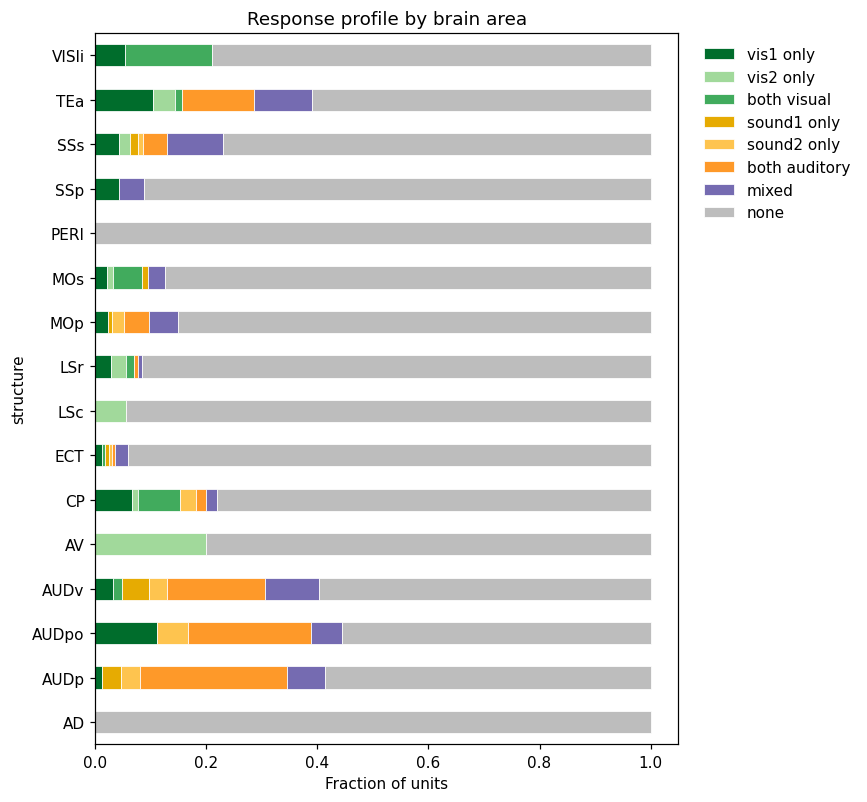

In [96]:
label_order = [
    'vis1 only', 'vis2 only', 'both visual',
    'sound1 only', 'sound2 only', 'both auditory',
    'mixed', 'none',
]

label_colors = [
    '#006d2c', '#a1d99b', '#41ab5d',   # visual categories (greens)
    '#e6ab02', '#fec44f', '#fe9929',   # auditory categories (yellows/ambers)
    '#756bb1', '#bdbdbd',              # mixed (purple), none (gray)
]

# Fraction of units in each response category, per brain area.
fraction_by_area = (unit_response_labels
                    .groupby(['structure', 'label']).size()
                    .unstack(fill_value=0))
fraction_by_area = fraction_by_area.loc[fraction_by_area.sum(axis=1) >= 3]
fraction_by_area = fraction_by_area.div(fraction_by_area.sum(axis=1), axis=0)
fraction_by_area = fraction_by_area.reindex(columns=label_order, fill_value=0)

fraction_by_area.plot(kind='barh', stacked=True,
                      figsize=(8, 0.4 * len(fraction_by_area) + 1),
                      color=label_colors, edgecolor='white', linewidth=0.5)
plt.xlabel('Fraction of units')
plt.title('Response profile by brain area')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
plt.tight_layout()
plt.show()

Auditory areas (`AUDp`, `AUDv`) are dominated by yellow bars — auditory-responsive units. Visual areas are dominated by green bars. Higher-order and association areas often show a broader palette, including purple bars for units driven by *both* modalities.

---
## 9. Does attention change the response?

So far we've treated every stimulus as the same, but remember that the animal was switching between two contexts:

- **attend-visual** blocks — a visual target (`vis1`) is rewarded
- **attend-auditory** blocks — an auditory target (`sound1`) is rewarded

So, although the same sound1 stimulus is presented in both both blocks, in one block it is associated with a reward and in another it is not. If attention matters, the neuron should respond differently depending on which modality the animal is currently attending. Let's compare responses between these two different blocks.

### 9.1 Split `sound1` trials by context

Take all `sound1` trials, separate them into "attend-vis" and "attend-aud" subsets and plot a PSTH.

sound1 in attend-aud blocks (attended)   : 64
sound1 in attend-vis blocks (unattended) : 54


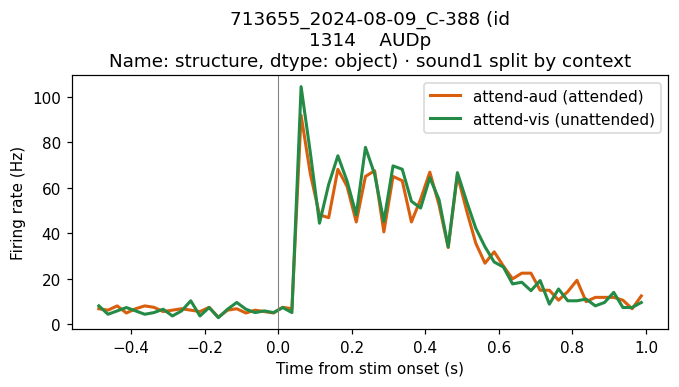

In [97]:
# Separate stimulus start times into sound1 rewarded (aud) or unrewarded (vis) trials
is_sound1         = trials['stim_name'] == 'sound1'
sound1_attended   = trials.loc[is_sound1 & (trials['rewarded_modality'] == 'aud'),
                               'stim_start_time'].to_numpy() # Find rows where stim_name is sound1 and rewarded_modality matches the stimulus type (aud)
sound1_unattended = trials.loc[is_sound1 & (trials['rewarded_modality'] == 'vis'),
                               'stim_start_time'].to_numpy() # Same but where rewarded_modality does not match the stimulus type (vis)

print(f'sound1 in attend-aud blocks (attended)   : {len(sound1_attended)}')
print(f'sound1 in attend-vis blocks (unattended) : {len(sound1_unattended)}')

# Calculate psth separately for attended and unattended trials
time_centers_att, rate_att = generate_psth(spike_times, sound1_attended)
time_centers_un,  rate_un  = generate_psth(spike_times, sound1_unattended)

plt.figure(figsize=(7, 3))
plt.plot(time_centers_att, rate_att, color=context_colors['attend-aud'],
         lw=2, label='attend-aud (attended)')
plt.plot(time_centers_un,  rate_un,  color=context_colors['attend-vis'],
         lw=2, label='attend-vis (unattended)')
plt.axvline(0, color='0.5', lw=0.7)
plt.xlabel('Time from stim onset (s)')
plt.ylabel('Firing rate (Hz)')
plt.title(f'{select_id} ({area}) · sound1 split by context')
plt.legend()
plt.show()

For our AUDp unit, the responses in both contexts (attend-vis and attend-aud) look very similar. The neuron is **context-invariant**. This is in line with what we expect for primary auditory cortex, which faithfully encodes the auditory stimulus regardless of attentional state.

Attention effects are more likely to appear in *downstream* areas where sensory input meets task demand. To find those neurons, we need to quantify the effect of attention on the stimulus-driven responses.

---
## 10. Attention Modulation Index (AMI)

Let's create a formula that quantifies how neural responses to the same stimulus changes during attended vs unattended blocks. We'll call this the **Attention Modulation Index** for now. Here is the logic:

1. Define a response window - here, we'll use 250ms after stimulus onset. In line with what we've been doing already.


2. compute mean firing rates during attended and unattended trials

- $r_\mathrm{attended}$ — average across trials where the presented modality **is** rewarded
- $r_\mathrm{unattended}$ — average across trials where presented modality **is not** rewarded

3. compare firing rates across attended and unattended trials.

We want a score that is:
- **positive** when the neuron fires more on attended trials, **negative** when it fires less,
- **zero** when the two rates are equal,
- on the **same scale** for a low firing (1-2Hz) as for a high firing one (50-100Hz)

This formula accomplishes what we want:

$$
\mathrm{AMI} \;=\; \frac{r_\mathrm{attended} \;-\; r_\mathrm{unattended}}
                        {r_\mathrm{attended} \;+\; r_\mathrm{unattended}}
$$


| AMI value | Definition |
|---|---|
| **> 0** | response **enhanced** by attention |
| **< 0** | response **suppressed** by attention |
| **≈ 0** | context-invariant — attention doesn't matter |

This is a general formula that can be applied for assessing normalized differences or modulation effects. Since we're comparing attended and unattended blocks, we're assessing the effect of attention but this can be applied to other contexts, such as reward modulation, stimulus selectivity, etc.

### 10.1 Compute Attention Modulation Index for our AUDp unit on `sound1` trials


In [98]:
response_window = (0.0, 0.25)   # define time window (250ms after stimulus onset)
window_duration = response_window[1] - response_window[0]

# Calculate mean firing rate in the response window on each set of trials.
rate_attended   = count_in_window(spike_times, sound1_attended,   *response_window).mean() / window_duration
rate_unattended = count_in_window(spike_times, sound1_unattended, *response_window).mean() / window_duration

# Plug into the AMI formula.
ami = (rate_attended - rate_unattended) / (rate_attended + rate_unattended)

print(f'attended trials (animal listening) = {rate_attended} Hz')
print(f'unattended trials (animal watching) = {rate_unattended} Hz')
print(f' AMI = {ami}')

attended trials (animal listening) = 50.625 Hz
unattended trials (animal watching) = 56.148148148148145 Hz
 AMI = -0.05172787581841041


---
## 11. Which neurons *are* modulated by attention?

For our AUDp unit, `AMI ≈ 0`. One hypothesis is that the primary auditory cortex sits close to the sensory input — it reports the sound whether the animal cares or not. Attention effects are more likely to appear in downstream areas: higher sensory cortex, association cortex, motor cortex.

Let's scale up our analysis to include all units across all brain areas.

1. Compute AMI for **every QC-pass unit × every stimulus** where the unit actually responds.
2. Keep only the stimulus responses where the attended vs unattended difference is statistically significant
3. Sort the responses by the size of the attention effect ( `|AMI|` ).

### 11.1 Wrap the AMI calculation into a function

Same formula as above but backed as a function in which we pass any (unit, stimulus) pair. Also returns a p-value for the attended-vs-unattended difference to assess significance. Here, we use an unpaired t-test (Welch's) plus Bonferroni correction because the attended and unattended trials come from different trials, so we treat these an independent samples.

In [99]:
def attention_modulation_index(spike_times, trials_df, stim_name,
                               window=(0.0, 0.25)):
    """Compute AMI for one stimulus type.

    Returns a dict with:
      ami             – (attended − unattended) / (attended + unattended), [−1, +1]
      rate_attended   – mean firing rate on attended trials (Hz)
      rate_unattended – mean firing rate on unattended trials (Hz)
      p_value         – attended-vs-unattended difference (Welch t-test)
    """
    # For a visual stimulus, "attended" = attend-visual blocks; for auditory, vice versa.
    modality = 'vis' if stim_name.startswith('vis') else 'aud'

    # Split this stimulus's trials by which modality is currently rewarded.
    stim_trials       = trials_df[trials_df['stim_name'] == stim_name]
    attended_onsets   = stim_trials.loc[stim_trials['rewarded_modality'] == modality,
                                        'stim_start_time'].to_numpy()
    unattended_onsets = stim_trials.loc[stim_trials['rewarded_modality'] != modality,
                                        'stim_start_time'].to_numpy()

    # Per-trial firing rate in the response window, for each set of trials.
    window_duration  = window[1] - window[0]
    rates_attended   = count_in_window(spike_times, attended_onsets,   *window) / window_duration
    rates_unattended = count_in_window(spike_times, unattended_onsets, *window) / window_duration

    # Aggregate → AMI + significance test.
    rate_attended   = rates_attended.mean()
    rate_unattended = rates_unattended.mean()
    ami             = (rate_attended - rate_unattended) / (rate_attended + rate_unattended + 1e-9)
    _, p_value      = stats.ttest_ind(rates_attended, rates_unattended, equal_var=False)

    return {
        'ami':             ami,
        'rate_attended':   rate_attended,
        'rate_unattended': rate_unattended,
        'p_value':         p_value,
    }

In [100]:
# For every QC-pass unit × every stimulus the unit responds to, compute the AMI.

responsive_pairs = unit_stim_tests[unit_stim_tests['responsive']] # get unit and stim pairs that were classified as responsive earlier
responsive_pairs = set(zip(responsive_pairs['unit_id'], responsive_pairs['stim']))

records = []
for _, unit_row in units[units['is_qc_pass']].iterrows():
    unit_spike_times = np.asarray(unit_row['spike_times'])

    for stim_name in ['vis1', 'vis2', 'sound1', 'sound2']:
        if (unit_row['unit_id'], stim_name) not in responsive_pairs:
            continue

        result = attention_modulation_index(unit_spike_times, trials, stim_name)
        records.append({
            'unit_id':       unit_row['unit_id'],
            'structure':     unit_row['structure'],
            'stim':          stim_name,
            'attended_Hz':   result['rate_attended'],
            'unattended_Hz': result['rate_unattended'],
            'ami':           result['ami'],
            'p_value':       result['p_value'],
        })

attention_results = pd.DataFrame(records)
print(f'{len(attention_results)} (unit, stimulus) pairs where the unit responds to the stimulus')
attention_results.head()

433 (unit, stimulus) pairs where the unit responds to the stimulus


,unit_id,structure,stim,attended_Hz,unattended_Hz,ami,p_value
0,713655_2024-08-09_A-11,AV,vis2,7.127273,5.962264,0.089003,2.477293e-01
1,713655_2024-08-09_A-142,MOp,sound2,11.185185,24.581818,-0.374553,7.883716e-11
2,713655_2024-08-09_A-150,MOp,sound1,14.625000,17.629630,-0.093153,8.728329e-02
3,713655_2024-08-09_A-150,MOp,sound2,14.814815,13.745455,0.037442,5.061808e-01
4,713655_2024-08-09_A-167,MOp,sound1,8.250000,6.814815,0.095267,1.852963e-01


### Reading the AMI table

Each row above is one **(neuron, stimulus)** pair:

| Column | Definition |
|---|---|
| `stim` | Which stimulus this AMI was computed for. A neuron that responds to all four stimuli contributes four rows. |
| `attended_Hz` | Mean firing rate on trials of `stim` when the animal was attending to that modality (e.g. for `sound1`, attend-auditory blocks). |
| `unattended_Hz` | Mean firing rate on trials of `stim` when the animal was attending to the other modality. |
| `ami` | The Attention Modulation Index, [−1, +1]. |
| `p_value` | outcome of Welch's t-test |

### 11.2 Filter for significantly modulated neurons and sort by size of the effect

We're back in the multiple-comparisons setting from Section 8.1: one Welch t-test per (unit, stimulus) pair means hundreds of p-values, so we again apply a **Bonferroni correction** before deciding what counts as significant.

We also want to filter out two other things:

1. Pairs where both firing rates are so **small** that AMI is unstable: filter by `attended_Hz + unattended_Hz > 10`.
2. After that, sort by the *size* of the AMI ( `|AMI|` ) so that both suppressive and enhancing effects rise to the top.

In [101]:
alpha = 0.05

# Bonferroni-corrected p-values: one t-test per (unit, stimulus) pair in the table.
n_tests = attention_results['p_value'].notna().sum()
attention_results['p_bonferroni'] = (attention_results['p_value'] * n_tests).clip(upper=1)

# Filter for significant and substantial attention effects.
attention_modulated = attention_results[
    (attention_results['p_bonferroni'] < alpha) &
    (attention_results['attended_Hz'] + attention_results['unattended_Hz'] > 10)
].copy()

# Sort by the absolute value of the AMI
attention_modulated['abs_ami'] = attention_modulated['ami'].abs()
attention_modulated = attention_modulated.sort_values('abs_ami', ascending=False)

print(f'{len(attention_modulated)} of {n_tests} pairs have a significant, substantial '
      f'attention effect (Bonferroni-corrected, alpha={alpha})')
attention_modulated.head(10)

59 of 433 pairs have a significant, substantial attention effect (Bonferroni-corrected, alpha=0.05)


,unit_id,structure,stim,attended_Hz,unattended_Hz,ami,p_value,p_bonferroni,abs_ami
246,713655_2024-08-09_C-640,TEa,sound1,0.500000,9.777778,-0.902703,4.903837e-13,2.123361e-10,0.902703
424,713655_2024-08-09_F-432,MOs,vis2,1.309091,10.037736,-0.769259,1.643240e-13,7.115231e-11,0.769259
355,713655_2024-08-09_E-209,MOp,sound2,11.111111,2.036364,0.690227,3.028892e-11,1.311510e-08,0.690227
292,713655_2024-08-09_C-964,TEa,sound2,9.407407,1.745455,0.686994,7.299260e-12,3.160579e-09,0.686994
244,713655_2024-08-09_C-634,TEa,sound2,12.666667,2.545455,0.665339,2.272799e-10,9.841220e-08,0.665339
41,713655_2024-08-09_B-160,SSs,sound2,23.037037,4.945455,0.646532,5.697907e-11,2.467194e-08,0.646532
354,713655_2024-08-09_E-209,MOp,sound1,17.125000,3.925926,0.627007,8.478560e-16,3.671216e-13,0.627007
243,713655_2024-08-09_C-634,TEa,sound1,10.625000,2.444444,0.625930,5.866426e-08,2.540163e-05,0.625930
249,713655_2024-08-09_C-645,TEa,sound1,2.875000,9.481481,-0.534657,1.288917e-08,5.581012e-06,0.534657
40,713655_2024-08-09_B-160,SSs,sound1,25.000000,8.518519,0.491713,1.272083e-08,5.508120e-06,0.491713


### Discuss

Pick out a few units - what do you notice?

- **`E-209`** in `MOp` (primary motor cortex) shows up near the top on **both** `sound1` and `sound2` — its firing rate is 4–5× higher on attended trials than unattended ones for auditory stimuli.
- Notice that `E-209`'s `sound2` row (AMI = +0.69) ranks *above* its `sound1` row (AMI = +0.63), even though the neuron fires *more* on `sound1` than on `sound2` (17 Hz vs 11 Hz when attended). That's because **AMI measures the *relative* effect of attention, not the absolute response strength**: for `sound2`, the unattended rate is low (2 Hz), so the ratio between attended and unattended is even bigger.
- **`TEa`** (temporal association area) units come up frequently on the list - this is a downstream area that mixes sensory input with task-relevant information.

### 11.3 Unit`E-209` in MOp

Let's look at an example - get the unit table data for `E-209` and plot PSTHs across the 8 conditions (4 stimuli: vis1, vis2, sound1, sound2; 2 contexts: attend-vis, attend-aud).

In [102]:
unit_id     = '713655_2024-08-09_E-209'
unit_row    = units.loc[units['unit_id'] == unit_id].iloc[0]
area        = unit_row['structure']
spike_times = np.asarray(unit_row['spike_times'])

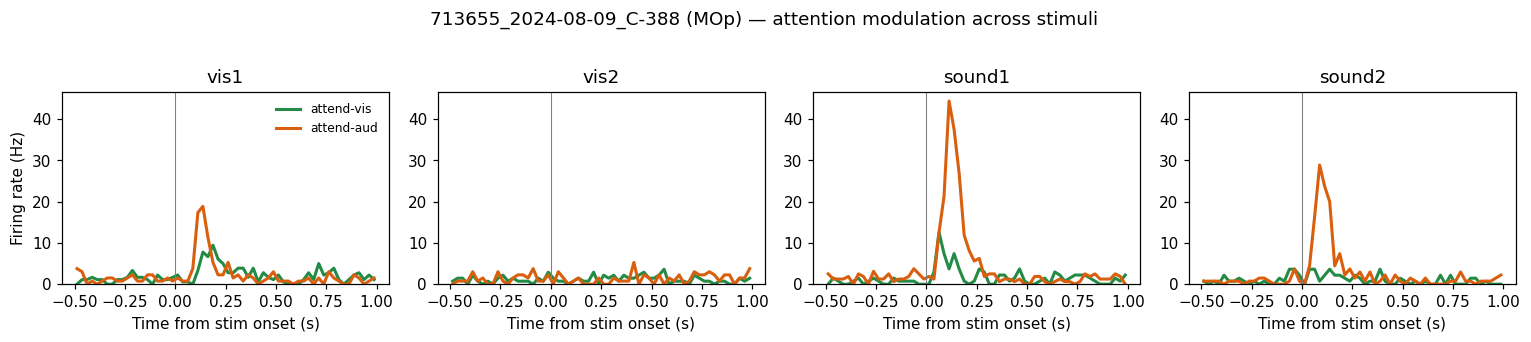

In [103]:
stimuli = ['vis1', 'vis2', 'sound1', 'sound2']
contexts = {'attend-vis': 'vis', 'attend-aud': 'aud'}  # context label -> rewarded_modality value

# Compute a PSTH for every (stimulus, context) combination first,
rates = {}            # empty dictionary to store firing rate response for every stimuli
time_centers = None   # time_centers same across all, so store one

for stim in stimuli:
    is_stim = trials['stim_name'] == stim
    rates[stim] = {}
    for context, modality in contexts.items():
        onsets = trials.loc[is_stim & (trials['rewarded_modality'] == modality), 'stim_start_time'].to_numpy()
        if len(onsets):
            time_centers, rates[stim][context] = generate_psth(spike_times, onsets)
        else:
            rates[stim][context] = None   # if no trials of this type, pass

# Find the highest y_value across stimulus, context to set ylim
y_max = max(
    rate.max()
    for stim_rates in rates.values()
    for rate in stim_rates.values()
    if rate is not None
)

# Setup figure
plt.figure(figsize=(14, 3))

for i, stim in enumerate(stimuli): # iterate across stimuli
    plt.subplot(1, 4, i + 1)

    for context in contexts: # iterate between two contexts
        rate = rates[stim][context]
        if rate is not None:
            plt.plot(time_centers, rate, color=context_colors[context], lw=2, label=context)

    # Create vertical line at stim onset
    plt.axvline(0, color='0.5', lw=0.7)
    # Set ylim as max plus some extra
    plt.ylim(0, y_max * 1.05)
    # Labelling code
    plt.title(stim)
    plt.xlabel('Time from stim onset (s)')
    if i == 0:
        plt.ylabel('Firing rate (Hz)')
        plt.legend(frameon=False, fontsize=8, loc='upper right')

plt.suptitle(f'{select_id} ({area}) — attention modulation across stimuli', y=1.02)
plt.tight_layout()
plt.show()

### Interpreting the plot above

Each panel shows the neural activity responses to each stimulus (`vis1`, `vis2`, `sound1`, `sound2`). The two lines separate the *context* the animal is in, or which stimulus type was rewarded (auditory or visual).

---
## 12. Wrap up

### Summary

- Primary sensory neurons (like `C-388` in AUDp) fire in response to auditory stimuli and are context invariant
- Downstream neurons in higher-order and motor areas (like `E-209` in MOp) respond much more strongly to the *same* sensory input when the animal is attending to it.

### Discussion

1. Why might a **primary auditory** neuron *not* care about attention, while a **motor-cortex** neuron with an auditory response *does*? Think about what each area is "for" in the task.
2. Our AMI collapses the entire response window down to one number. Where inside a trial (early vs late after onset) would you expect the attention effect to be strongest, and why?
3. Suppose the animal moves more during attend-auditory blocks than during attend-visual blocks. How could that inflate a positive AMI? What would you plot to argue the effect is really *attention* and not just *arousal* or *movement*?
4. `A-142` (also in MOp) has a large **negative** AMI on auditory stimuli — it fires *less* when the animal is attending to sound. Can you think of a reason a task-relevant neuron might be suppressed rather than enhanced?
